<a href="https://colab.research.google.com/github/marcuslee6/Signal-and-Systems/blob/main/Fourier%20Transform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

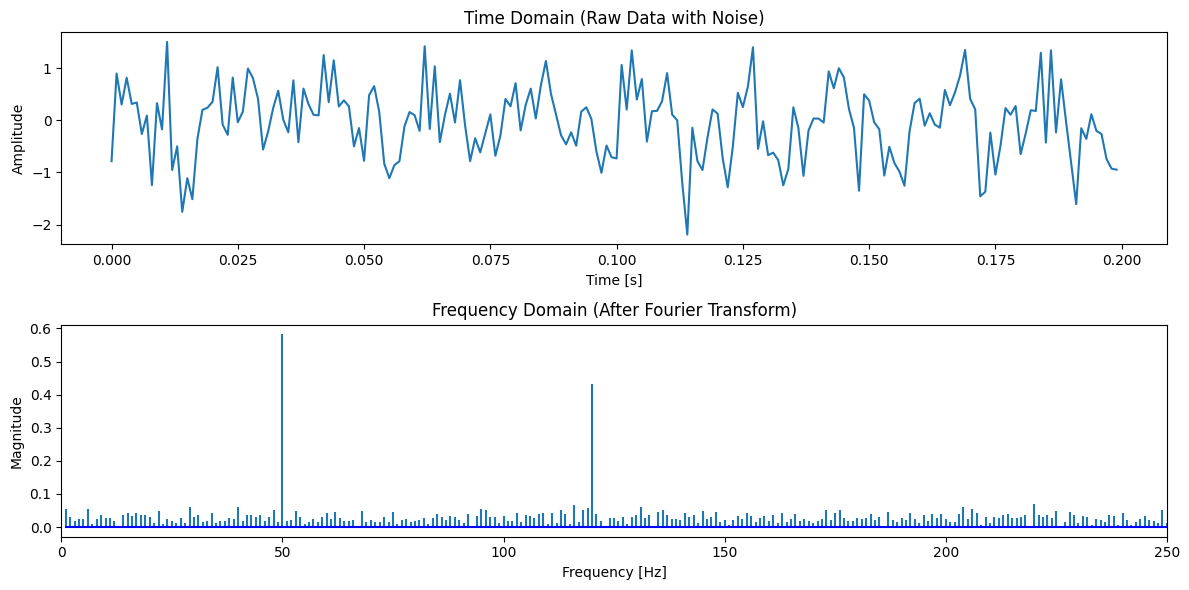

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Set parameters
sampling_rate = 1000 # Sampling Frequency (Hz)
duration = 1.0
t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)

# 2. Set up signal
# Hypothesize 2 frequencies：50Hz 和 120Hz，add random noise
freq1, freq2 = 50, 120
signal = 0.6 * np.sin(2 * np.pi * freq1 * t) + 0.4 * np.sin(2 * np.pi * freq2 * t)
noise = 0.5 * np.random.normal(size=t.shape)
data = signal + noise

# 3. Fourier Transform
# Important Procedure of Feature Extraction in Data Science
fft_result = np.fft.fft(data)
fft_freqs = np.fft.fftfreq(len(t), 1/sampling_rate)

# Extract positive Frequency to Plot
pos_mask = fft_freqs > 0
freqs_to_plot = fft_freqs[pos_mask]
magnitude = np.abs(fft_result[pos_mask]) * 2 / len(t)

# 4. Visualization Result
plt.figure(figsize=(12, 6))

# Time Domain
plt.subplot(2, 1, 1)
plt.plot(t[:200], data[:200]) # Only show 200 points
plt.title("Time Domain (Raw Data with Noise)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

# Frequency Domain
plt.subplot(2, 1, 2)
plt.stem(freqs_to_plot, magnitude, markerfmt=" ", basefmt="-b")
plt.xlim(0, 250) # Focus on specific frequency ranges
plt.title("Frequency Domain (After Fourier Transform)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()